In [606]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [607]:
def load_data(path, limit=None):
    df = pd.read_csv(path, header=None, nrows=limit)
    labels = df.iloc[:, 0].values
    images = df.iloc[:, 1:].values.astype(np.float32)
    print(images.shape)
    images = images / 255.0
    images = (images - np.mean(images))/np.std(images)
    print(images.size)

    return images.reshape(-1, 28, 28), labels

In [608]:
train_images, train_labels = load_data("mnist_train.csv", limit=2000)
test_images, test_labels = load_data("mnist_test.csv", limit=700)

(2000, 784)
1568000
(700, 784)
548800


In [609]:
np.random.seed(2)
indices = np.random.permutation(len(train_images))
split = int(0.8 * len(indices))

train_idx = indices[:split]
val_idx = indices[split:]

X_train, y_train = train_images[train_idx], train_labels[train_idx]
X_val, y_val = train_images[val_idx], train_labels[val_idx]

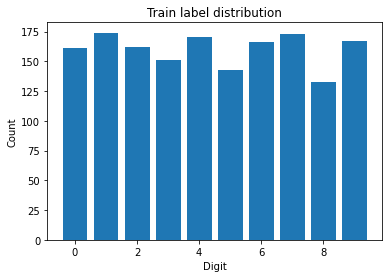

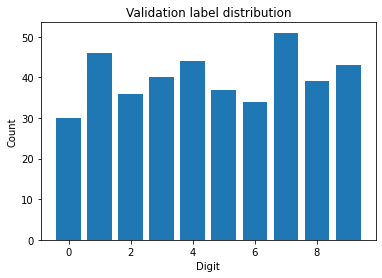

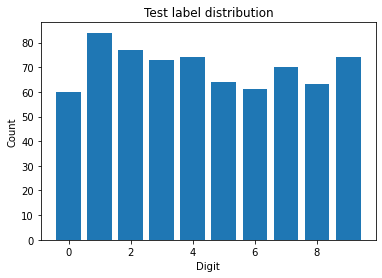

In [610]:
def plot_label_distribution(y, title):
    classes, counts = np.unique(y, return_counts=True)
    plt.bar(classes, counts)
    plt.xlabel("Digit")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

plot_label_distribution(y_train, "Train label distribution")
plot_label_distribution(y_val, "Validation label distribution")
plot_label_distribution(test_labels, "Test label distribution")

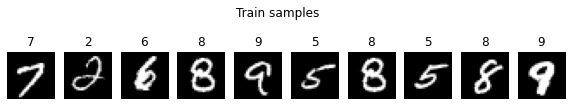

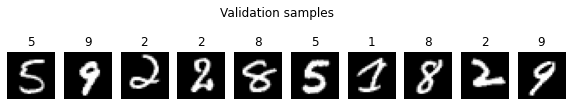

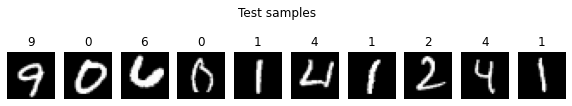

In [611]:
def show_images(images, labels, title, n=10):
    plt.figure(figsize=(10,2))
    for i in range(n):
        idx = np.random.randint(len(images))
        plt.subplot(1, n, i+1)
        plt.imshow(images[idx], cmap="gray")
        plt.title(labels[idx])
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_images(X_train, y_train, "Train samples")
show_images(X_val, y_val, "Validation samples")
show_images(test_images, test_labels, "Test samples")

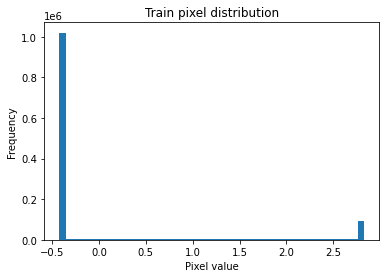

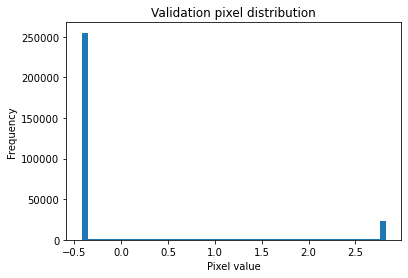

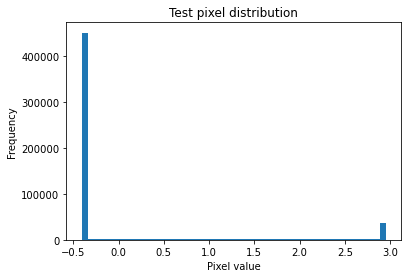

In [612]:
def plot_pixel_hist(images, title):
    pixels = images.reshape(-1)
    plt.hist(pixels, bins=50)
    plt.xlabel("Pixel value")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

plot_pixel_hist(X_train, "Train pixel distribution")
plot_pixel_hist(X_val, "Validation pixel distribution")
plot_pixel_hist(test_images, "Test pixel distribution")

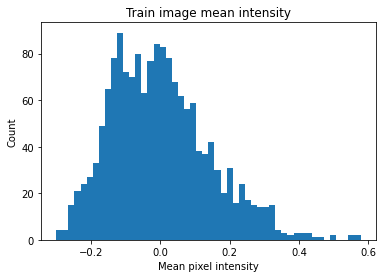

In [613]:
def image_intensity_stats(images, title):
    means = images.mean(axis=(1,2))

    plt.hist(means, bins=50)
    plt.xlabel("Mean pixel intensity")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

    return means

train_means = image_intensity_stats(X_train, "Train image mean intensity")

In [614]:
low = np.percentile(train_means, 1)
high = np.percentile(train_means, 99)

outliers = np.where((train_means < low) | (train_means > high))[0]
print("Number of outliers:", len(outliers))

Number of outliers: 32


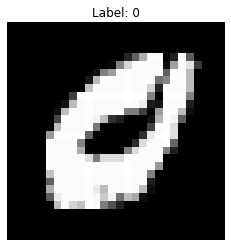

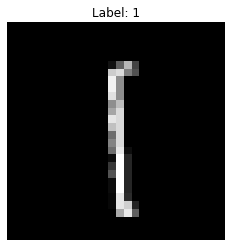

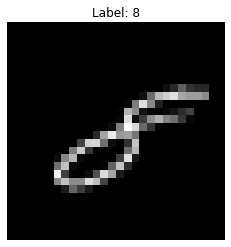

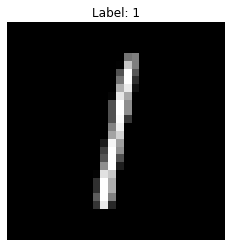

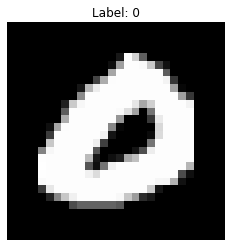

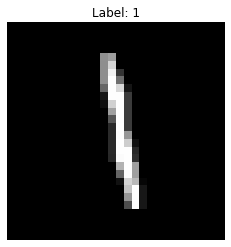

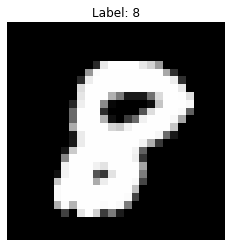

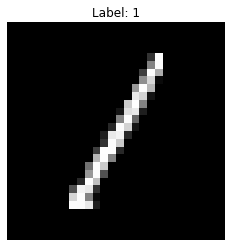

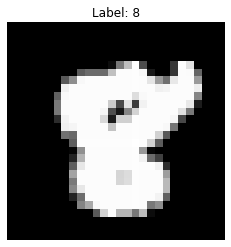

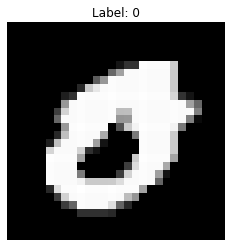

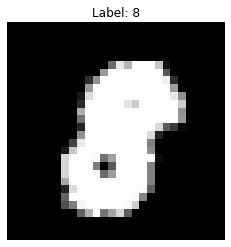

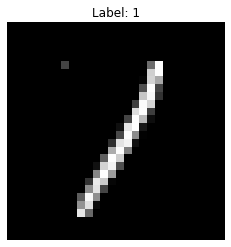

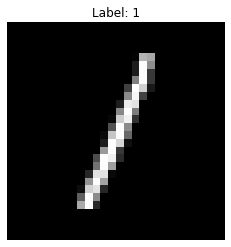

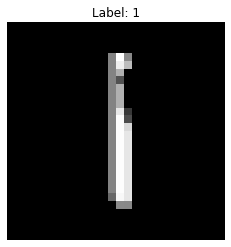

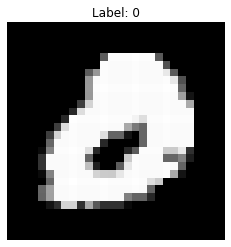

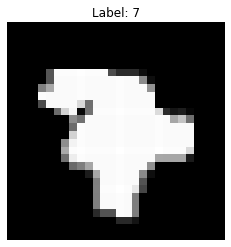

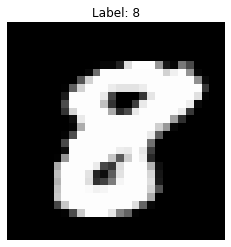

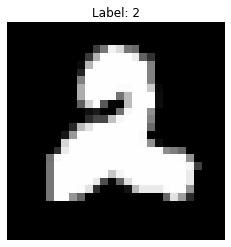

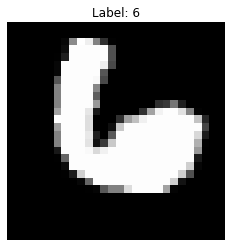

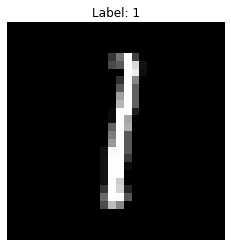

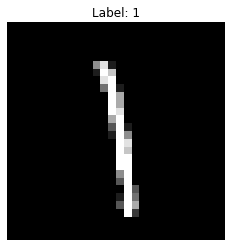

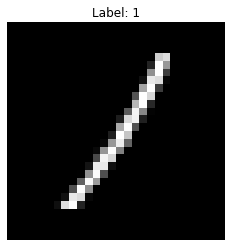

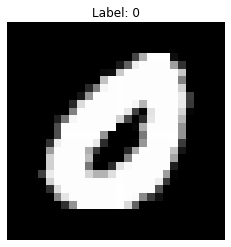

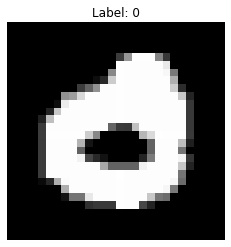

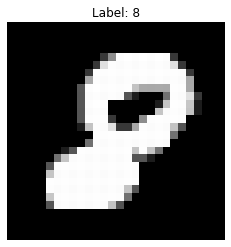

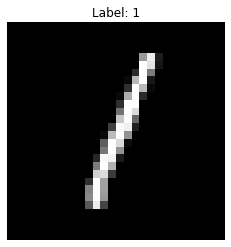

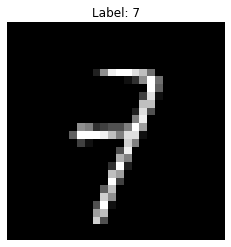

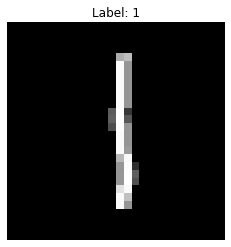

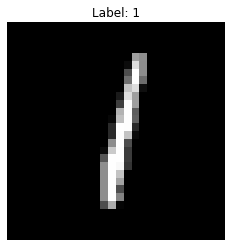

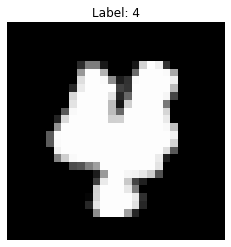

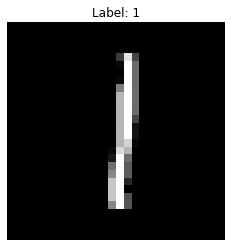

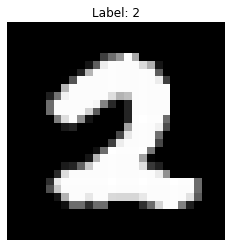

In [615]:
for idx in outliers:
    plt.imshow(X_train[idx], cmap="gray")
    plt.title(f"Label: {y_train[idx]}")
    plt.axis("off")
    plt.show()

In [616]:
def remove_outliers_by_intensity(images, labels, low_pct=1, high_pct=99):
    means = images.mean(axis=(1, 2))

    low = np.percentile(means, low_pct)
    high = np.percentile(means, high_pct)

    mask = (means >= low) & (means <= high)

    print(f"Removed {np.sum(~mask)} outliers out of {len(images)}")

    return images[mask], labels[mask]

In [617]:
X_train, y_train = remove_outliers_by_intensity(X_train, y_train)
X_val, y_val     = remove_outliers_by_intensity(X_val, y_val)
test_images, test_labels = remove_outliers_by_intensity(test_images, test_labels)

Removed 32 outliers out of 1600
Removed 8 outliers out of 400
Removed 14 outliers out of 700


In [ ]:
class Conv3x3:
    def __init__(self, num_filters, in_channels):
        self.filters = np.random.randn(num_filters, 3, 3, in_channels) / 9
        self.d_filters = np.zeros_like(self.filters)

        # Adam
        self.m = np.zeros_like(self.filters)
        self.v = np.zeros_like(self.filters)
        self.t = 0

    def forward(self, x):
        if x.ndim == 2:
            x = x[:, :, np.newaxis]

        self.last_input = x
        h, w, c = x.shape
        f = self.filters.shape[0]

        out = np.zeros((h - 2, w - 2, f))

        for i in range(h - 2):
            for j in range(w - 2):
                region = x[i:i+3, j:j+3, :]
                out[i, j] = np.sum(region * self.filters, axis=(1,2,3))

        self.last_output = np.maximum(0, out)
        return self.last_output

    def backprop(self, d_out):
        d_out[self.last_output <= 0] = 0
        d_input = np.zeros_like(self.last_input)

        for i in range(d_out.shape[0]):
            for j in range(d_out.shape[1]):
                for f in range(d_out.shape[2]):
                    self.d_filters[f] += d_out[i,j,f] * self.last_input[i:i+3, j:j+3, :]
                    d_input[i:i+3, j:j+3, :] += d_out[i,j,f] * self.filters[f]

        return d_input

    def step(self, lr, l2, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        g = self.d_filters + l2 * self.filters

        self.m = beta1 * self.m + (1 - beta1) * g
        self.v = beta2 * self.v + (1 - beta2) * (g ** 2)

        m_hat = self.m / (1 - beta1 ** self.t)
        v_hat = self.v / (1 - beta2 ** self.t)

        self.filters -= lr * m_hat / (np.sqrt(v_hat) + eps)
        self.d_filters.fill(0)

In [ ]:
class MaxPool2:
    def forward(self, x):
        self.last_input = x
        h, w, c = x.shape
        out = np.zeros((h//2, w//2, c))

        for i in range(h//2):
            for j in range(w//2):
                region = x[i*2:i*2+2, j*2:j*2+2]
                out[i,j] = np.max(region, axis=(0,1))
        return out

    def backprop(self, d_out):
        d_input = np.zeros_like(self.last_input)

        h, w, c = self.last_input.shape
        for i in range(h//2):
            for j in range(w//2):
                region = self.last_input[i*2:i*2+2, j*2:j*2+2]
                max_vals = np.max(region, axis=(0,1))

                for a in range(2):
                    for b in range(2):
                        for ch in range(c):
                            if region[a,b,ch] == max_vals[ch]:
                                d_input[i*2+a, j*2+b, ch] = d_out[i,j,ch]
        return d_input

In [626]:
class Softmax:
    def __init__(self, input_len, nodes):
        self.W = np.random.randn(input_len, nodes) / input_len
        self.b = np.zeros(nodes)

        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)

        # Adam
        self.mW = np.zeros_like(self.W)
        self.vW = np.zeros_like(self.W)
        self.mb = np.zeros_like(self.b)
        self.vb = np.zeros_like(self.b)
        self.t = 0

    def forward(self, x):
        self.last_input_shape = x.shape
        self.last_input = x.flatten()

        z = self.last_input @ self.W + self.b
        exp = np.exp(z - np.max(z))
        self.out = exp / np.sum(exp)
        return self.out

    def backprop(self, label):
        # gradient of softmax + cross entropy
        grad = self.out.copy()
        grad[label] -= 1

        self.dW += np.outer(self.last_input, grad)
        self.db += grad

        return (self.W @ grad).reshape(self.last_input_shape)

    def step(self, lr, l2, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1

        gW = self.dW + l2 * self.W
        gb = self.db

        self.mW = beta1*self.mW + (1-beta1)*gW
        self.vW = beta2*self.vW + (1-beta2)*(gW**2)
        self.mb = beta1*self.mb + (1-beta1)*gb
        self.vb = beta2*self.vb + (1-beta2)*(gb**2)

        self.W -= lr * self.mW / (np.sqrt(self.vW)+eps)
        self.b -= lr * self.mb / (np.sqrt(self.vb)+eps)

        self.dW.fill(0)
        self.db.fill(0)

In [627]:
conv1 = Conv3x3(8, 1)
pool1 = MaxPool2()

conv2 = Conv3x3(16, 8)
pool2 = MaxPool2()

softmax = Softmax(5 * 5 * 16, 10)

In [631]:
epochs = 10
batch_size = 32
lr = 0.001
l2 = 1e-4

train_acc_hist = []
val_acc_hist = []

for epoch in range(epochs):
    perm = np.random.permutation(len(X_train))
    X_train, y_train = X_train[perm], y_train[perm]

    correct = 0

    for i in range(0, len(X_train), batch_size):
        for im, label in zip(X_train[i:i+batch_size], y_train[i:i+batch_size]):
            out = conv1.forward(im)
            out = pool1.forward(out)
            out = conv2.forward(out)
            out = pool2.forward(out)
            out = softmax.forward(out)

            correct += int(np.argmax(out) == label)

            grad = softmax.backprop(label)
            grad = grad.reshape(5,5,16)

            grad = pool2.backprop(grad)
            grad = conv2.backprop(grad)
            grad = pool1.backprop(grad)
            conv1.backprop(grad)

        conv1.step(lr,batch_size, l2)
        conv2.step(lr,batch_size, l2)
        softmax.step(lr, l2)
        print(
                f"\rProcessed: {i}/{len(X_train)} | ",
                end=""
            )

    train_acc = correct / len(X_train)
    val_acc = sum(
        np.argmax(
            softmax.forward(
                pool2.forward(
                    conv2.forward(
                        pool1.forward(conv1.forward(im))
                    )
                )
            )
        ) == y
        for im, y in zip(X_val, y_val)
    ) / len(X_val)

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train {train_acc:.3f} | Val {val_acc:.3f}")

Processed: 1536/1568 | Epoch 1/10 | Train 0.814 | Val 0.829
Processed: 1536/1568 | Epoch 2/10 | Train 0.878 | Val 0.872
Processed: 1536/1568 | Epoch 3/10 | Train 0.895 | Val 0.890
Processed: 1536/1568 | Epoch 4/10 | Train 0.917 | Val 0.903
Processed: 1536/1568 | Epoch 5/10 | Train 0.929 | Val 0.898
Processed: 1536/1568 | Epoch 6/10 | Train 0.940 | Val 0.913
Processed: 1536/1568 | Epoch 7/10 | Train 0.940 | Val 0.903
Processed: 1536/1568 | Epoch 8/10 | Train 0.948 | Val 0.926
Processed: 1536/1568 | Epoch 9/10 | Train 0.953 | Val 0.921
Processed: 1536/1568 | Epoch 10/10 | Train 0.954 | Val 0.926


In [661]:
for epoch in range(epochs):
    perm = np.random.permutation(len(X_train))
    X_train, y_train = X_train[perm], y_train[perm]

    correct = 0

    for i in range(0, len(X_train), batch_size):
        for im, label in zip(X_train[i:i+batch_size], y_train[i:i+batch_size]):
            out = conv1.forward(im)
            out = pool1.forward(out)
            out = conv2.forward(out)
            out = pool2.forward(out)
            out = softmax.forward(out)

            correct += int(np.argmax(out) == label)

            grad = softmax.backprop(label)
            grad = grad.reshape(5,5,16)

            grad = pool2.backprop(grad)
            grad = conv2.backprop(grad)
            grad = pool1.backprop(grad)
            conv1.backprop(grad)

        conv1.step(lr,batch_size, l2)
        conv2.step(lr,batch_size, l2)
        softmax.step(lr, l2)
        print(
                f"\rProcessed: {i}/{len(X_train)} | ",
                end=""
            )

    train_acc = correct / len(X_train)
    val_acc = sum(
        np.argmax(
            softmax.forward(
                pool2.forward(
                    conv2.forward(
                        pool1.forward(conv1.forward(im))
                    )
                )
            )
        ) == y
        for im, y in zip(X_val, y_val)
    ) / len(X_val)

    train_acc_hist.append(train_acc)
    val_acc_hist.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train {train_acc:.3f} | Val {val_acc:.3f}")

Processed: 1536/1568 | Epoch 1/10 | Train 0.957 | Val 0.921
Processed: 1536/1568 | Epoch 2/10 | Train 0.961 | Val 0.931
Processed: 1536/1568 | Epoch 3/10 | Train 0.966 | Val 0.926
Processed: 1536/1568 | Epoch 4/10 | Train 0.969 | Val 0.934
Processed: 1536/1568 | Epoch 5/10 | Train 0.969 | Val 0.936
Processed: 1536/1568 | Epoch 6/10 | Train 0.968 | Val 0.929
Processed: 1536/1568 | Epoch 7/10 | Train 0.973 | Val 0.931
Processed: 1536/1568 | Epoch 8/10 | Train 0.971 | Val 0.931
Processed: 1536/1568 | Epoch 9/10 | Train 0.977 | Val 0.931
Processed: 1536/1568 | Epoch 10/10 | Train 0.978 | Val 0.934


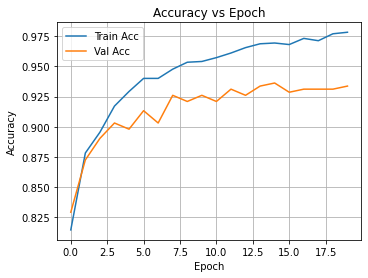

In [662]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [663]:
def get_predictions(images):
    preds = []
    for im in images:
        out = softmax.forward(pool2.forward(conv2.forward(pool1.forward(conv1.forward(im)))))
        preds.append(np.argmax(out))
    return np.array(preds)

y_pred = get_predictions(X_val)   # or test_images
y_true = y_val

In [664]:
def evaluate(images, labels):
    correct = 0

    for im, label in zip(images, labels):
        out = conv1.forward(im)
        out = pool1.forward(out)
        out = conv2.forward(out)
        out = pool2.forward(out)
        out = softmax.forward(out)

        if np.argmax(out) == label:
            correct += 1

    return correct / len(labels)

In [665]:
test_acc = evaluate(test_images, test_labels)
test_acc

0.9314868804664723

In [666]:
y_test_pred = get_predictions(test_images)

cm = confusion_matrix(test_labels, y_test_pred)
print(cm)

[[54  0  0  0  0  1  1  0  0  1]
 [ 0 78  0  0  0  0  0  0  0  0]
 [ 0  0 72  0  0  0  0  1  2  1]
 [ 0  0  1 61  0  5  1  1  2  0]
 [ 0  0  1  0 65  0  2  0  1  5]
 [ 0  0  0  1  0 61  0  1  0  1]
 [ 1  0  0  0  0  1 58  0  0  0]
 [ 0  0  2  1  0  0  0 65  0  1]
 [ 2  1  2  0  2  0  0  1 53  2]
 [ 0  0  0  0  0  0  0  2  0 72]]


<Figure size 576x576 with 0 Axes>

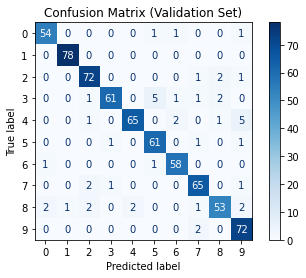

In [667]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

In [668]:
def show_images(images, y_true, y_pred, indices, title, max_show=10):
    n = min(len(indices), max_show)
    plt.figure(figsize=(2*n, 3))

    for i in range(n):
        idx = indices[i]
        plt.subplot(1, n, i+1)
        plt.imshow(images[idx], cmap="gray")
        plt.title(f"T:{y_true[idx]}  P:{y_pred[idx]}")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()


Digit 0: FP=2 FN=2


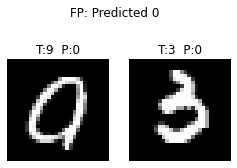

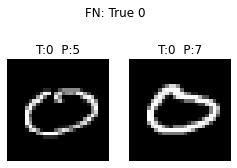


Digit 1: FP=1 FN=2


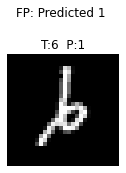

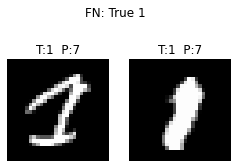


Digit 2: FP=5 FN=0


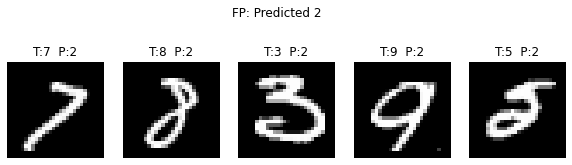


Digit 3: FP=2 FN=5


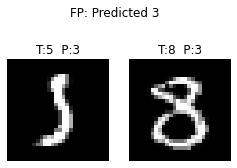

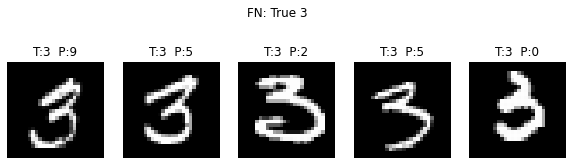


Digit 4: FP=1 FN=3


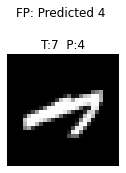

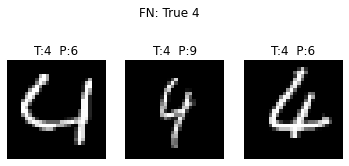


Digit 5: FP=4 FN=3


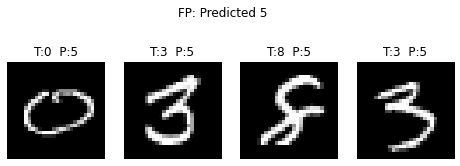

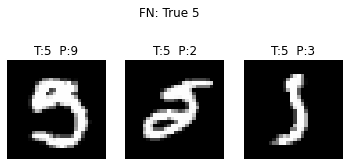


Digit 6: FP=4 FN=1


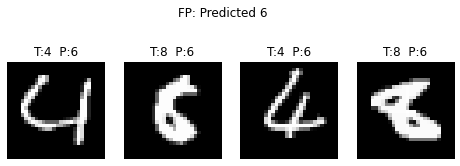

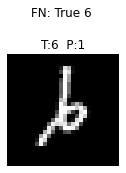


Digit 7: FP=4 FN=2


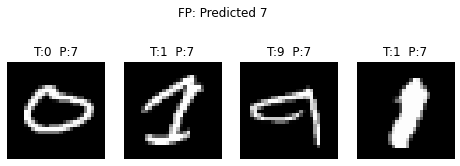

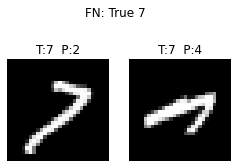


Digit 8: FP=0 FN=5


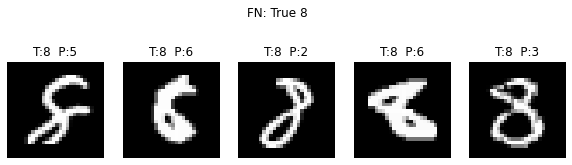


Digit 9: FP=3 FN=3


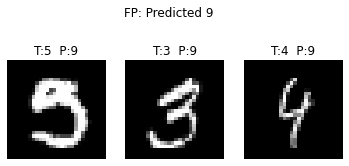

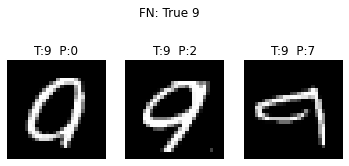

In [669]:
for digit in range(10):
    fp = np.where((y_pred == digit) & (y_true != digit))[0]
    fn = np.where((y_true == digit) & (y_pred != digit))[0]

    print(f"\nDigit {digit}: FP={len(fp)} FN={len(fn)}")

    if len(fp) > 0:
        show_images(X_val, y_true, y_pred, fp,
                    f"FP: Predicted {digit}", max_show=6)

    if len(fn) > 0:
        show_images(X_val, y_true, y_pred, fn,
                    f"FN: True {digit}", max_show=6)

In [670]:
im = X_train[0]
print(im.shape)

(28, 28)
